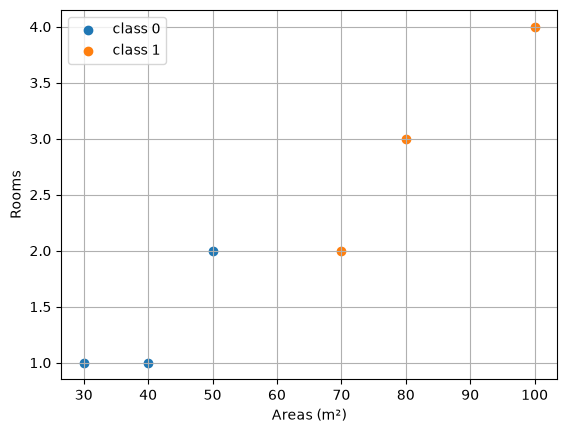

In [2]:
# data visualization
import numpy as np
import matplotlib.pyplot as plt

x = np.array([
    [30, 1],
    [40, 1],
    [50, 2],
    [70, 2],
    [80, 3],
    [100, 4]
])

y = np.array([0, 0, 0, 1, 1, 1])


plt.scatter(x[y==0,0], x[y==0,1], label="class 0")
plt.scatter(x[y==1,0], x[y==1,1], label="class 1")

plt.xlabel("Areas (m²)")
plt.ylabel("Rooms")
plt.grid(True)
plt.legend()
plt.show()

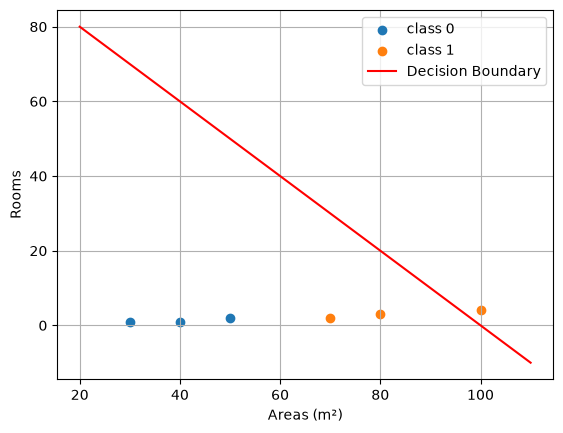

In [3]:
# boundary line

import numpy as np
import matplotlib.pyplot as plt

x = np.array([
    [30, 1],
    [40, 1],
    [50, 2],
    [70, 2],
    [80, 3],
    [100, 4]
])

y = np.array([0, 0, 0, 1, 1, 1])

plt.scatter(x[y==0,0], x[y==0,1], label="class 0")
plt.scatter(x[y==1,0], x[y==1,1], label="class 1")

#let w = [81,4] and b = -99 then  x1 = x2 -99
u = x[:, 0].min()-10
v = x[:, 0].max() + 10

x1 = np.linspace(u,v,100)



x2 = 100 - x1

# plt.figure(figsize=(8,6))
plt.xlabel("Areas (m²)")
plt.ylabel("Rooms")

plt.plot(x1, x2,  label="Decision Boundary",color="red", linestyle="-")
plt.grid(True)
plt.legend()
plt.show()

Now if you consider the consider the boundary line, the vector [70, 2] and [80, 3] are not properly classified, the prediction is 0 whereas the true label is 1, so we need to correct that by training the model, i.e adjusting the weight to change the slope and the bias to change the position

In [4]:
# True label and prediction
# y_true = 1
# y_pred = 0

# w←w+η(y−y^​)x
# b←b+η(y−y^​)

# Learning rate
# η = 1

# Calculate error
# error = y_true - y_pred

# Update weights
# w = w + eta * error * x
# w←w+η(y−y^​)x

# Update bias
# b = b + eta * error
# b←b+η(y−y^​)

# print("Updated weights:", w)
# print("Updated bias:", b)

# Test the same house again
# z = np.dot(w, x) + b

# prediction = 1 if z >= 0 else 0

# print("New score:", z)
# print("New prediction:", prediction)

## Now update the weights

The perceptron update rule is:
 w←w+η(y−y^​)x


We're using:

η=1 

and we already know:

y-y^ =1

and:

x=[80,3] 

Therefore:

w_new = [1,1]+(1)(1)[80,3] 

First:

 (1)(1)[80,3]=[80,3] 

So:

w_new=[1,1]+[80,3] 

giving:

w_new=[81,4]

This is the learning step.

The model has changed its weights because it made a mistake.

## Update the bias

The bias update is:

b←b+η(y−y^​)


We have:

b=-100  
η=1  
y-y^=1 

Therefore:

b_new=-100+(1)(1) 
b_new=-99

So after responding to the mistake, our parameters are:

w=[81,4] b=-99

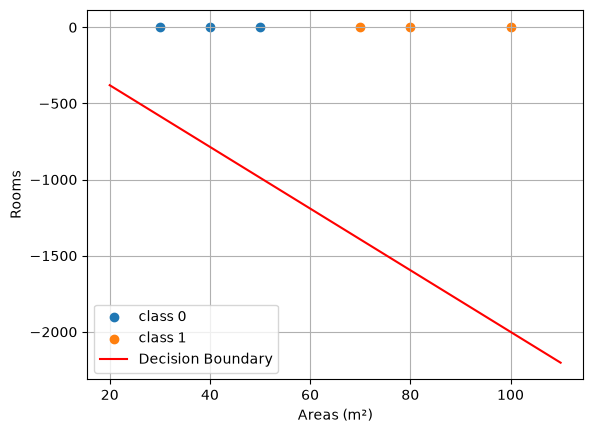

In [5]:
# now let's check the new weight

# boundary line


plt.scatter(x[y==0,0], x[y==0,1], label="class 0")
plt.scatter(x[y==1,0], x[y==1,1], label="class 1")

# w = [81,4] and b = -99 
# Therefore:
# x2 = 24.75 - 20.25*x1

u = x[:, 0].min()-10
v = x[:, 0].max() + 10

x1 = np.linspace(u,v,100)

w = np.array([81,4]) 
b = -99 

x2 = -(w[0] * x1 + b) / w[1]

# plt.figure(figsize=(8,6))
plt.xlabel("Areas (m²)")
plt.ylabel("Rooms")

plt.plot(x1, x2,  label="Decision Boundary",color="red", linestyle="-")
plt.grid(True)
plt.legend()
plt.show()

oops! As see here in the graph, it shows that One training example caused a change to the global decision boundary.The perceptron doesn't move the individual point.
It changes w and b, and those parameters define the entire line.

The next step is to take all six vectors and make the perceptron go through them one by one.

In [6]:
# Here we use a loop to iteratively adjust the weight and bias
w = np.array([0,0])
b = 0
eta = 1

for i in range(len(x)):
    x_i = x[i]
    y_i = y[i]

    z = np.dot(w, x_i) + b 

    result = 1 if z >= 0 else 0
    error = y_i - result

    print(f"House {i + 1}")
    print("  Features:", x_i)
    print("  True label:", y_i)
    print("  Score:", z)
    print("  Prediction:", y_pred)
    print("  Error:", error)

    if error != 0:
        w = w + eta * error * x_i
        b= b + eta * error
        print("  ❌ Mistake! Updated parameters.")
    else:
        print("  ✅ Correct! No update.")


    


House 1
  Features: [30  1]
  True label: 0
  Score: 0


NameError: name 'y_pred' is not defined

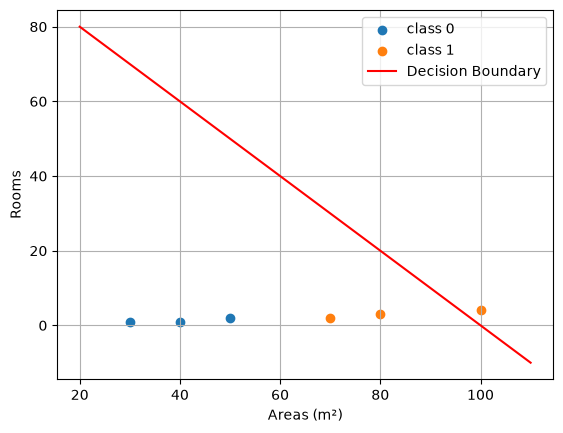

House 1
  Features: [30  1]
  True label: 0
  Score: 0.0
  Prediction: 1
  Error: -1
House 2
  Features: [40  1]
  True label: 0
  Score: -1202.0
  Prediction: 0
  Error: 0
House 3
  Features: [50  2]
  True label: 0
  Score: -1503.0
  Prediction: 0
  Error: 0
House 4
  Features: [70  2]
  True label: 1
  Score: -2103.0
  Prediction: 0
  Error: 1
House 5
  Features: [80  3]
  True label: 1
  Score: 3203.0
  Prediction: 1
  Error: 0
House 6
  Features: [100   4]
  True label: 1
  Score: 4004.0
  Prediction: 1
  Error: 0
Epoch 1: mistakes = 2, w = [40.  1.], b = 0.0
House 1
  Features: [30  1]
  True label: 0
  Score: 1201.0
  Prediction: 1
  Error: -1
House 2
  Features: [40  1]
  True label: 0
  Score: 399.0
  Prediction: 1
  Error: -1
House 3
  Features: [50  2]
  True label: 0
  Score: -1504.0
  Prediction: 0
  Error: 0
House 4
  Features: [70  2]
  True label: 1
  Score: -2104.0
  Prediction: 0
  Error: 1
House 5
  Features: [80  3]
  True label: 1
  Score: 3202.0
  Prediction: 1
  

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

x = np.array([
    [30, 1],
    [40, 1],
    [50, 2],
    [70, 2],
    [80, 3],
    [100, 4]
])

y = np.array([0, 0, 0, 1, 1, 1])

plt.scatter(x[y==0,0], x[y==0,1], label="class 0")
plt.scatter(x[y==1,0], x[y==1,1], label="class 1")

#let w = [81,4] and b = -99 then  x1 = x2 -99
u = x[:, 0].min()-10
v = x[:, 0].max() + 10

x1 = np.linspace(u,v,100)



x2 = 100 - x1

# plt.figure(figsize=(8,6))
plt.xlabel("Areas (m²)")
plt.ylabel("Rooms")

plt.plot(x1, x2,  label="Decision Boundary",color="red", linestyle="-")
plt.grid(True)
plt.legend()
plt.show()




w = np.array([0.0, 0.0])
b = 0.0

eta = 1.0
epochs = 10

for epoch in range(epochs):

    mistakes = 0

    for i in range(len(x)):
        x_i = x[i]
        y_i = y[i]

        z = np.dot(w, x_i) + b

        y_pred = 1 if z >= 0 else 0

        error = y_i - y_pred

        print(f"House {i + 1}")
        print("  Features:", x_i)
        print("  True label:", y_i)
        print("  Score:", z)
        print("  Prediction:", y_pred)
        print("  Error:", error)

        if error != 0:
            w = w + eta * error * x_i
            b = b + eta * error
            mistakes += 1

    print(
        f"Epoch {epoch + 1}: "
        f"mistakes = {mistakes}, "
        f"w = {w}, "
        f"b = {b}"
    )

what is notice here,  The perceptron learning rule itself does not guarantee that every arbitrary training setup will look smooth.


Final learned weights: w = [4.  0.1], b = -1.9000000000000004


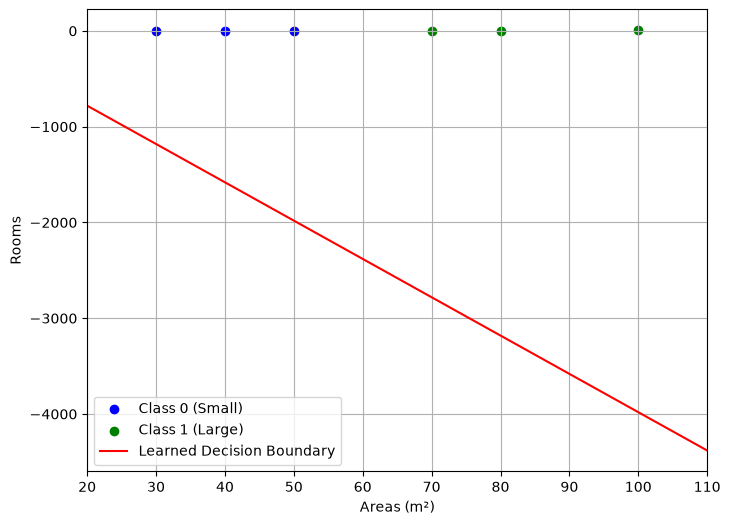

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dataset
x = np.array([[30, 1], [40, 1], [50, 2], [70, 2], [80, 3], [100, 4]])
y = np.array([0, 0, 0, 1, 1, 1])

# For Perceptron tracking, map 0 to -1
y_perceptron = np.where(y == 0, -1, 1)

# 2. Perceptron Training
w = np.array([0.0, 0.0])
b = 0.0
eta = 0.1  # Lower learning rate helps stability
epochs = 20

for epoch in range(epochs):
    mistakes = 0
    for i in range(len(x)):
        x_i = x[i]
        y_i = y_perceptron[i]

        z = np.dot(w, x_i) + b
        y_pred = 1 if z >= 0 else -1
        error = y_i - y_pred

        if error != 0:
            w = w + eta * (y_i) * x_i  # Standard Perceptron update rule
            b = b + eta * y_i
            mistakes += 0.5  # Error is 2 or -2, so we scale mistakes count

    # Break early if perfectly classified
    if mistakes == 0:
        print(f"Converged early at Epoch {epoch + 1}!")
        break

print(f"\nFinal learned weights: w = {w}, b = {b}")

# 3. Dynamic Decision Boundary Calculation
# w0*x1 + w1*x2 + b = 0  ->  x2 = (-w0*x1 - b) / w1
u = x[:, 0].min() - 10
v = x[:, 0].max() + 10
x1_range = np.linspace(u, v, 100)

if w[1] != 0:
    x2_range = (-w[0] * x1_range - b) / w[1]
else:
    x2_range = np.zeros_like(x1_range)

# 4. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0, 0], x[y == 0, 1], label="Class 0 (Small)", color="blue")
plt.scatter(x[y == 1, 0], x[y == 1, 1], label="Class 1 (Large)", color="green")

plt.plot(
    x1_range,
    x2_range,
    label="Learned Decision Boundary",
    color="red",
    linestyle="-",
)

plt.xlabel("Areas (m²)")
plt.ylabel("Rooms")
plt.xlim(u, v)
# plt.ylim(x[:, 1].min() - 1, x[:, 1].max() + 1)
plt.grid(True)
plt.legend()
plt.show()


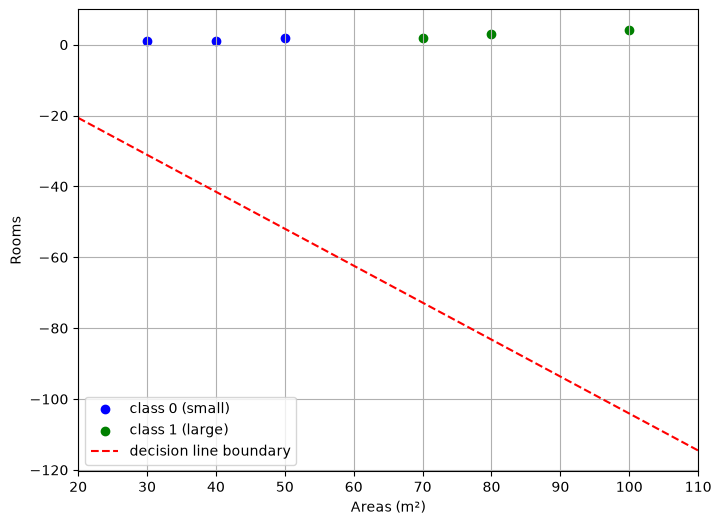

In [ ]:
# feature scaling with a single one epoch

mean = np.mean(x, axis=0)
std = np.std(x, axis=0)

x_scaled = (x - mean)/ std

w = np.array([0, 0])
b = 0
eta =0.1

for i in range(len(x_scaled)):
    x_i = x_scaled[i]
    y_i = y[i]

    z = np.dot(w,x_i) + b

    result = 1 if z >= 0 else 0

    error = result - y_i

    w = w + eta * error * x_i
    b = b + eta * error

u = x[:,0].min()-10
v = x[:, 0].max() + 10

x1 = np.linspace(u,v, 100)

if w[1] != 0:
    x2 = (-w[0] * x1 - b)/w[1]
else:
    x2 = np.zeros_like(x1)

plt.figure(figsize=(8,6))

plt.scatter(x[y==0, 0], x[y==0, 1], label="class 0 (small)", color="blue")
plt.scatter(x[y==1, 0], x[y==1, 1], label="class 1 (large)", color="green")


plt.plot(x1, x2, label="decision line boundary", color="red", linestyle="--")
plt.xlabel("Areas (m²)")
plt.ylabel("Rooms")
plt.xlim(u, v)
plt.grid(True)
plt.legend()
plt.show()
